In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [10]:
import os, re, sys
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
import hist
from hist import Hist
import mplhep as hep
import uproot

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

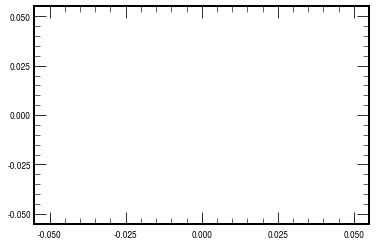

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

In [11]:
def merge_runs(plots, run):
    names = [
        "Higgs",
        "TTV",
        "ST_NLO",
        "WJets",
        "VV+VVV",
        "TT_powheg",
        "DY",
        "QCD_Pt_MuEnrichedPt5",
    ]
    # Add signal processes
    signal_processes = list(
        set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13TeV", p))
    )
    # Remove 2016APV for now
    # years = ["2016APV", "2016", "2017", "2018"]
    years = ["2016", "2017", "2018"]
    if run == "Run3":
        names.remove("TTV")
        names.remove("ST_NLO")
        years = ["2022", "2022EE", "2023", "2023BPix"]
        # Add signal processes
        signal_processes = list(
            set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13p6TeV", p))
        )
    names.append("Data")
    names.extend(signal_processes)
    run_plots = {}
    for name in names:
        run_plots[f"{name}_{run}"] = {}
        for year in years:
            if f"{name}_{year}" not in plots.keys():
                continue
            for plot in plots[f"{name}_{year}"]:
                if plot not in run_plots[f"{name}_{run}"].keys():
                    run_plots[f"{name}_{run}"][plot] = plots[f"{name}_{year}"][
                        plot
                    ].copy()
                else:
                    run_plots[f"{name}_{run}"][plot] += plots[f"{name}_{year}"][plot]
    return run_plots

In [13]:
plots = {}
years_to_load = [
    "2016",
    "2017",
    "2018",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
]
for year in track(years_to_load, description="Loading plots"):
    plots = plots | plot_utils.loader(
        tag=f"full_analysis_Jun2025_{year}_CR",
        era=year,
        load_data=True,
    )
run2_plots = merge_runs(plots, "Run2")
plots = plots | run2_plots
run3_plots = merge_runs(plots, "Run3")
plots = plots | run3_plots

Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

In [21]:
run2_to_run3_lumi = 118118.024269 / 62407.853016

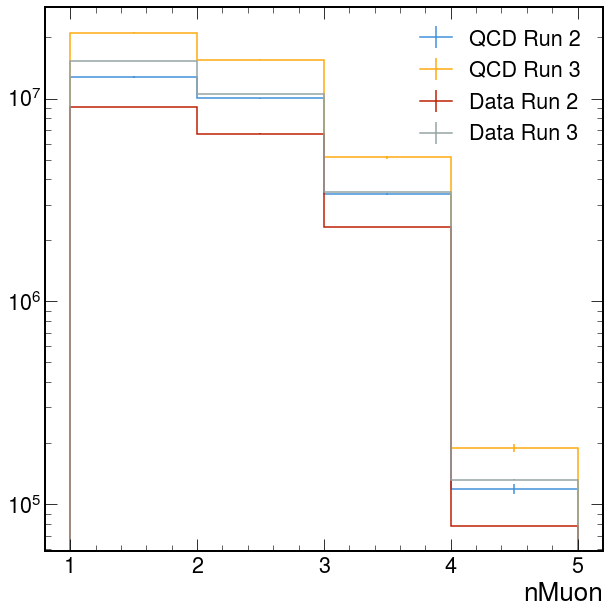

In [24]:
(plots["QCD_Pt_MuEnrichedPt5_Run2"]["CR_cb"] / run2_to_run3_lumi).plot(
    label="QCD Run 2"
)
plots["QCD_Pt_MuEnrichedPt5_Run3"]["CR_cb"].plot(label="QCD Run 3")
(plots["Data_Run2"]["CR_cb"] / run2_to_run3_lumi).plot(label="Data Run 2")
plots["Data_Run3"]["CR_cb"].plot(label="Data Run 3")
plt.yscale("log")
plt.legend()
plt.show()